# Vietnam Gold Price Study — Phase 3: ARDL Bounds Test & Long-Run Estimation
**Paper:** Modeling the Impact of Exchange Rate Volatility on Domestic Gold Prices in Vietnam  
**Input:** `vietnam_gold_data/master_data.xlsx` (Phase 1) · Phase 2 confirmed all variables I(1)  
**Output:** `vietnam_gold_data/phase3_results.xlsx` · `phase3_plots/`

---
## Phase 3 sequence
| Cell | Step | Purpose |
|---|---|---|
| 3 | Optimal lag selection | AIC/BIC/HQ for ARDL(p,q₁,...,q₄) |
| 4 | ARDL bounds test (F-stat) | Test for cointegration — Pesaran et al. 2001 |
| 5 | Long-run coefficients | Level relationship between variables |
| 6 | Error Correction Model (ECM) | Short-run dynamics + speed of adjustment |
| 7 | ARDL diagnostics | BG serial correlation · BPG heteroskedasticity · Normality |
| 8 | CUSUM stability tests | Parameter stability over 2015–2025 |
| 9 | GARCH(1,1) robustness | Address ARCH effects in residuals (Phase 2 finding) |
| 10 | Results summary | Publication-ready tables + economic interpretation |

## ARDL model specification

The unrestricted ECM form estimated in Cell 3–4 (Pesaran, Shin & Smith 2001, Case III):

$$\Delta\ln(SJC_t) = \alpha_0 + \sum_{i=1}^{p}\beta_i\Delta\ln(SJC_{t-i}) + \sum_{j=0}^{q_1}\gamma_j\Delta\ln(EXRATE_{t-j}) + \sum_{j=0}^{q_2}\delta_j\Delta\ln(GOLD_{W,t-j}) + \sum_{j=0}^{q_3}\phi_j\Delta\ln(CPI_{t-j}) + \sum_{j=0}^{q_4}\psi_j\Delta IR_{t-j} + \lambda_1\ln(SJC_{t-1}) + \lambda_2\ln(EXRATE_{t-1}) + \lambda_3\ln(GOLD_{W,t-1}) + \lambda_4\ln(CPI_{t-1}) + \lambda_5 IR_{t-1} + \theta_1 D_{\text{covid}} + \theta_2 D_{\text{sbv24}} + \varepsilon_t$$

where the **bounds test** tests H₀: $\lambda_1 = \lambda_2 = \lambda_3 = \lambda_4 = \lambda_5 = 0$ (no long-run levels relationship).

The **long-run cointegrating vector** (derived in Cell 5) is:

$$\ln(SJC_t) = \frac{-\alpha_0}{\lambda_1} - \frac{\lambda_2}{\lambda_1}\ln(EXRATE_t) - \frac{\lambda_3}{\lambda_1}\ln(GOLD_{W,t}) - \frac{\lambda_4}{\lambda_1}\ln(CPI_t) - \frac{\lambda_5}{\lambda_1} IR_t + u_t$$

The **speed of adjustment** $\hat{\lambda}_1$ must be negative and significant for a valid ECM.

> **Requires:** `pip install statsmodels arch`  
> **Run order:** Cell 1 → 2 → 3 → 4 → 5 → 6 → 7 → 8 → 9 → 10


---
## Cell 1 · Imports & setup

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from itertools import product

import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import (
    acorr_breusch_godfrey, het_breuschpagan, het_white
)
from statsmodels.stats.stattools import jarque_bera
from statsmodels.tsa.stattools import acf
from scipy import stats as scipy_stats

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 130, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})

INPUT_FILE  = os.path.join('vietnam_gold_data', 'master_data.xlsx')
OUTPUT_DIR  = 'vietnam_gold_data'
PLOT_DIR    = os.path.join(OUTPUT_DIR, 'phase3_plots')
os.makedirs(PLOT_DIR, exist_ok=True)

# Pesaran et al. (2001) Table CI(iii): Case III — unrestricted intercept, no trend
# k = 4 regressors, T ≈ 130
# Critical values: [lower I(0), upper I(1)]
PESARAN_CV = {
    '1%' : (3.74, 5.06),
    '5%' : (2.86, 4.01),
    '10%': (2.45, 3.52),
}

print('[OK] Imports complete')
print(f'     Input  : {os.path.abspath(INPUT_FILE)}')
print(f'     Plots  : {os.path.abspath(PLOT_DIR)}')
print()
print('Pesaran et al. (2001) critical values — Case III, k=4:')
for level, (lo, hi) in PESARAN_CV.items():
    print(f'  {level}: I(0) lower = {lo:.2f}  |  I(1) upper = {hi:.2f}')


[OK] Imports complete
     Input  : c:\Users\Admin\.vscode\ts prj\vietnam_gold_data\master_data.xlsx
     Plots  : c:\Users\Admin\.vscode\ts prj\vietnam_gold_data\phase3_plots

Pesaran et al. (2001) critical values — Case III, k=4:
  1%: I(0) lower = 3.74  |  I(1) upper = 5.06
  5%: I(0) lower = 2.86  |  I(1) upper = 4.01
  10%: I(0) lower = 2.45  |  I(1) upper = 3.52


---
## Cell 2 · Load data from Phase 1

In [2]:
master = pd.read_excel(INPUT_FILE, sheet_name='master_data',
                       index_col='date', parse_dates=True)

# ── Variable definitions ──────────────────────────────────────────────────────
DEPVAR   = 'lGOLD_SJC'                               # dependent variable
REGRESSORS = ['lEXRATE', 'lGOLD_W', 'lCPI', 'IR']   # level regressors (for cointegration)
DUMMIES  = ['D_covid', 'D_sbv24']                    # structural break dummies
ALL_LEVELS = [DEPVAR] + REGRESSORS

# First-differenced series
DDEPVAR  = 'dlGOLD_SJC'
DREGS    = ['dlEXRATE', 'dlGOLD_W', 'dlCPI', 'dIR']

# ── Tết seasonal dummy ───────────────────────────────────────────────────────
# BG lag-12 FAIL signals seasonal autocorrelation (Tết gold-buying cycle)
# D_tet = 1 in January and February of each year
master['D_tet'] = master.index.month.isin([1, 2]).astype(int)
DUMMIES = ['D_covid', 'D_sbv24', 'D_tet']   # add D_tet
print('Added D_tet seasonal dummy (Jan/Feb = 1)')
print(f'D_tet=1 count: {master["D_tet"].sum()} months')

# Drop the first row (NaN from differencing)
data = master.dropna(subset=[DDEPVAR])

print(f'Dataset  : {data.shape[0]} obs × {data.shape[1]} cols')
print(f'Sample   : {data.index[0].date()} → {data.index[-1].date()}')
print(f'Dep var  : {DEPVAR}')
print(f'Regressors (levels): {REGRESSORS}')
print(f'Dummies  : {DUMMIES}')
data[ALL_LEVELS + DUMMIES].tail(3)


Added D_tet seasonal dummy (Jan/Feb = 1)
D_tet=1 count: 22 months
Dataset  : 131 obs × 17 cols
Sample   : 2015-02-01 → 2025-12-01
Dep var  : lGOLD_SJC
Regressors (levels): ['lEXRATE', 'lGOLD_W', 'lCPI', 'IR']
Dummies  : ['D_covid', 'D_sbv24', 'D_tet']


,lGOLD_SJC,lEXRATE,lGOLD_W,lCPI,IR,D_covid,D_sbv24,D_tet
date,,,,,,,,
2025-10-01,18.815422,10.179084,8.289590,4.912410,4.5,1,1,0
2025-11-01,18.858290,10.179155,8.347187,4.915374,4.5,1,1,0
2025-12-01,18.888808,10.178521,8.372306,4.918339,4.5,1,1,0


---
## Cell 3 · Optimal lag selection

### What it does
The ARDL(p, q₁, q₂, q₃, q₄) model requires choosing the lag length for each variable.
We search over all combinations up to `MAX_LAG = 4` (appropriate for monthly data, T=131)
and select the model minimising **AIC** (Akaike Information Criterion).
BIC and HQ are also reported as cross-checks — they penalise extra parameters more heavily
and typically select shorter lags.

### The ARDL-in-levels approach (Pesaran 2001)
The ARDL bounds test runs an unrestricted ECM in levels — it does not pre-difference
the data. The regression includes:
- Lagged first differences of all variables (short-run dynamics)
- One-period lagged levels of all variables (long-run levels relationship)
- Structural break dummies D_covid, D_sbv24

> **Note:** Searching all combinations with MAX_LAG=4 and 5 variables
> evaluates 5⁴ = 625 models. This may take 30–60 seconds.


In [ ]:
MAX_LAG = 4   # Schwert (1989): [12(T/100)^0.25] ≈ 12 for T=131; use 4 for parsimony

def build_ardl_regressors(data, dep, regs, dregs, dummies,
                           p, qs, include_const=True):
    """
    Build the ARDL-ECM regressor matrix.
    Includes: p lags of Δdep, q_i lags of Δreg_i (including lag 0),
              one lag of all levels variables, dummies.
    Returns (X, y, feature_names).
    """
    T = len(data)
    cols = {}

    # ── Lagged differences of dependent variable ──────────────────────────────
    ddep = data[dep].diff()   # Δdep (already in data but recompute for safety)
    for lag in range(1, p + 1):
        cols[f'd{dep}_L{lag}'] = ddep.shift(lag)

    # ── Current and lagged differences of regressors ──────────────────────────
    for reg, dreg, q in zip(regs, dregs, qs):
        dreg_s = data[dreg]
        for lag in range(0, q + 1):
            cols[f'd{reg}_L{lag}'] = dreg_s.shift(lag)

    # ── One-period lagged levels (cointegration terms) ────────────────────────
    for v in [dep] + regs:
        cols[f'{v}_L1'] = data[v].shift(1)

    # ── Dummies ───────────────────────────────────────────────────────────────
    for d in dummies:
        cols[d] = data[d]

    X = pd.DataFrame(cols, index=data.index)
    if include_const:
        X = sm.add_constant(X)

    y = data[dep].diff()   # Δdep is the dependent variable in ECM form

    # Drop rows with any NaN (from lags)
    combined = pd.concat([y, X], axis=1).dropna()
    y_clean  = combined.iloc[:, 0]
    X_clean  = combined.iloc[:, 1:]
    return X_clean, y_clean


def fit_ardl(data, dep, regs, dregs, dummies, p, qs):
    """Fit ARDL-ECM and return (result, aic, bic, hq, nobs)."""
    X, y = build_ardl_regressors(data, dep, regs, dregs, dummies, p, qs)
    if len(y) < len(X.columns) + 2:   # need at least k+2 obs
        return None, np.inf, np.inf, np.inf, 0
    try:
        # statsmodels 0.14+ requires explicit maxlags in cov_kwds for HAC
        res = OLS(y, X).fit(cov_type='HAC',
                            cov_kwds={'maxlags': None, 'use_correction': True})
        k   = res.df_model + 1  # number of parameters
        n   = res.nobs
        aic = res.aic
        bic = res.bic
        hq  = -2 * res.llf + 2 * k * np.log(np.log(n))
        return res, aic, bic, hq, int(n)
    except Exception:
        return None, np.inf, np.inf, np.inf, 0


# ── Grid search over all lag combinations ────────────────────────────────────
print('Searching ARDL lag combinations (p=0..4, q₁..q₄=0..4)...')
print('Total models to evaluate:', (MAX_LAG+1)**5)

results = []
for p in range(1, MAX_LAG + 1):          # p ≥ 1 for lagged dep var
    for qs in product(range(MAX_LAG + 1), repeat=4):
        res, aic, bic, hq, nobs = fit_ardl(
            data, DEPVAR, REGRESSORS, DREGS, DUMMIES, p, list(qs)
        )
        if res is not None:
            results.append({
                'p'   : p,
                'q_EXRATE': qs[0], 'q_GOLDW': qs[1],
                'q_CPI': qs[2], 'q_IR': qs[3],
                'AIC' : round(aic, 3),
                'BIC' : round(bic, 3),
                'HQ'  : round(hq,  3),
                'Obs' : nobs,
            })

lag_df = pd.DataFrame(results)

# Best models by each criterion
best_aic = lag_df.loc[lag_df['AIC'].idxmin()]
best_bic = lag_df.loc[lag_df['BIC'].idxmin()]
best_hq  = lag_df.loc[lag_df['HQ'].idxmin()]

print()
print('OPTIMAL LAG SELECTION')
print('=' * 60)
for crit, best in [('AIC', best_aic), ('BIC', best_bic), ('HQ', best_hq)]:
    print(f'  {crit}: ARDL({int(best.p)},{int(best.q_EXRATE)},{int(best.q_GOLDW)},'
          f'{int(best.q_CPI)},{int(best.q_IR)})  '
          f'{crit}={best[crit]:.3f}  Obs={int(best.Obs)}')

# Use AIC-selected model
OPT_P  = int(best_aic.p)
OPT_QS = [int(best_aic.q_EXRATE), int(best_aic.q_GOLDW),
           int(best_aic.q_CPI),    int(best_aic.q_IR)]

print()
print(f'Selected (AIC): ARDL({OPT_P},{OPT_QS[0]},{OPT_QS[1]},{OPT_QS[2]},{OPT_QS[3]})')
print('Top 5 by AIC:')
print(lag_df.nsmallest(5, 'AIC').to_string(index=False))

---
## Cell 4 · ARDL bounds test (F-statistic) — Pesaran, Shin & Smith (2001)

### What it does
The bounds test checks whether a **long-run cointegrating relationship** exists among the
five variables without pre-specifying whether they are I(0) or I(1).
It tests the joint null **H₀: λ₁ = λ₂ = λ₃ = λ₄ = λ₅ = 0** — i.e. no levels relationship.

The F-statistic is compared against two bounds:
- **Lower bound I(0):** assumes all regressors are stationary → more lenient.
- **Upper bound I(1):** assumes all regressors have unit roots → more demanding.

| F-stat vs bounds | Conclusion |
|---|---|
| F > upper I(1) bound | Cointegration confirmed |
| F < lower I(0) bound | No cointegration |
| lower < F < upper | Inconclusive |

### Specification
Case III (Pesaran 2001): unrestricted intercept, no trend — appropriate because
all variables trend upward in levels (captured by the constant in the ECM).
k = 4 regressors. Critical values from Table CI(iii).


In [5]:
# ── Fit the AIC-selected ARDL model ──────────────────────────────────────────
ardl_res, _, _, _, _ = fit_ardl(
    data, DEPVAR, REGRESSORS, DREGS, DUMMIES, OPT_P, OPT_QS
)

print(f'ARDL({OPT_P},{OPT_QS[0]},{OPT_QS[1]},{OPT_QS[2]},{OPT_QS[3]}) — full results')
print(f'Observations     : {int(ardl_res.nobs)}')
print(f'R-squared        : {ardl_res.rsquared:.4f}')
print(f'Adj. R-squared   : {ardl_res.rsquared_adj:.4f}')
print(f'F-stat (model)   : {ardl_res.fvalue:.4f}  p={ardl_res.f_pvalue:.4f}')
print(f'AIC              : {ardl_res.aic:.3f}')
print(f'BIC              : {ardl_res.bic:.3f}')
print()

# ── Bounds F-test: test joint significance of lagged level terms ──────────────
# Level variables: lGOLD_SJC_L1, lEXRATE_L1, lGOLD_W_L1, lCPI_L1, IR_L1
# Only test the five pure level terms — exclude lagged-difference terms (dl*_L1)
level_cols = [
    c for c in ardl_res.model.exog_names
    if c.endswith('_L1')
    and not c.startswith('dl')      # exclude Δ-lagged terms
    and not c.startswith('d')        # exclude dIR_L1 etc.
    and c != 'const'
]
# Should be exactly: lGOLD_SJC_L1, lEXRATE_L1, lGOLD_W_L1, lCPI_L1, IR_L1
print(f'Correct level terms ({len(level_cols)}): {level_cols}')
assert len(level_cols) == 5, (
    f'Expected 5 level terms, found {len(level_cols)}: {level_cols}\n'
    'Check that REGRESSORS has exactly 4 variables.'
)
print(f'Level (cointegration) terms: {level_cols}')

# Wald test: H0 = all level coefficients = 0

# Use F-test via restriction matrix
param_names = ardl_res.model.exog_names
level_idx   = [param_names.index(c) for c in level_cols]

R = np.zeros((len(level_idx), len(param_names)))
for i, idx in enumerate(level_idx):
    R[i, idx] = 1.0

wald = ardl_res.f_test(R)
bounds_f = float(wald.fvalue)
bounds_p = float(wald.pvalue)

print()
print('ARDL BOUNDS TEST')
print('=' * 60)
print(f'  H₀: no long-run levels relationship (λ₁=...=λ₅=0)')
print(f'  F-statistic (bounds) : {bounds_f:.4f}')
print(f'  p-value              : {bounds_p:.4f}')
print()
print('  Pesaran et al. (2001) critical values — Case III, k=4:')
print(f'  {"Level":<6} {"I(0) lower":>12} {"I(1) upper":>12} {"F-stat":>10} {"Decision":>20}')
for level, (lo, hi) in PESARAN_CV.items():
    if bounds_f > hi:
        decision = 'Cointegration'
    elif bounds_f < lo:
        decision = 'No cointegration'
    else:
        decision = 'Inconclusive'
    marker = ' <<' if bounds_f > hi else ''
    print(f'  {level:<6} {lo:>12.2f} {hi:>12.2f} {bounds_f:>10.4f} {decision:>20}{marker}')

print()
if bounds_f > PESARAN_CV['5%'][1]:
    print('✅ COINTEGRATION CONFIRMED at 5% — long-run relationship exists.')
    print('   Proceed to long-run coefficient estimation (Cell 5).')
elif bounds_f > PESARAN_CV['10%'][1]:
    print('⚠️  COINTEGRATION at 10% only — borderline result.')
    print('   Report with caution; use more parsimonious model.')
elif bounds_f < PESARAN_CV['10%'][0]:
    print('✗  NO COINTEGRATION — no long-run levels relationship.')
    print('   Estimation proceeds in first differences (pure ECM).')
else:
    print('⚠️  INCONCLUSIVE — F-stat between bounds.')
    print('   Try alternative lag length or Case IV specification.')


ARDL(1,0,1,1,0) — full results
Observations     : 129
R-squared        : 0.4719
Adj. R-squared   : 0.4018
F-stat (model)   : 3.7425  p=0.0000
AIC              : -539.809
BIC              : -494.052

Correct level terms (5): ['lGOLD_SJC_L1', 'lEXRATE_L1', 'lGOLD_W_L1', 'lCPI_L1', 'IR_L1']
Level (cointegration) terms: ['lGOLD_SJC_L1', 'lEXRATE_L1', 'lGOLD_W_L1', 'lCPI_L1', 'IR_L1']

ARDL BOUNDS TEST
  H₀: no long-run levels relationship (λ₁=...=λ₅=0)
  F-statistic (bounds) : 2.6273
  p-value              : 0.0275

  Pesaran et al. (2001) critical values — Case III, k=4:
  Level    I(0) lower   I(1) upper     F-stat             Decision
  1%             3.74         5.06     2.6273     No cointegration
  5%             2.86         4.01     2.6273     No cointegration
  10%            2.45         3.52     2.6273         Inconclusive

⚠️  INCONCLUSIVE — F-stat between bounds.
   Try alternative lag length or Case IV specification.


---
## Cell 5 · Long-run coefficients

### What it does
Derives the long-run (cointegrating) coefficients from the lagged level terms of the ARDL.
The long-run relationship (normalised on lGOLD_SJC) is:

$$\ln(SJC_t) = \beta_0 + \beta_1\ln(EXRATE_t) + \beta_2\ln(GOLD_{W,t}) + \beta_3\ln(CPI_t) + \beta_4 IR_t + u_t$$

where $\hat{\beta}_i = -\hat{\lambda}_i \,/\, \hat{\lambda}_{SJC}$, with $\hat{\lambda}_i$ the coefficient on the lagged level of variable $i$ and $\hat{\lambda}_{SJC}$ the coefficient on $\ln(SJC_{t-1})$.

### Expected signs
| Variable | Expected sign | Theory |
|---|---|---|
| lEXRATE | + | VND depreciation raises domestic gold price (PPP) |
| lGOLD_W | + | Pass-through from world to domestic gold price |
| lCPI | + | Inflation hedge demand raises gold price |
| IR | − | Higher rates reduce gold attractiveness (opportunity cost) |


In [6]:
# ── Extract lagged level coefficients from ARDL ──────────────────────────────
params     = ardl_res.params
bse        = ardl_res.bse
tvals      = ardl_res.tvalues
pvals      = ardl_res.pvalues
conf_int   = ardl_res.conf_int(alpha=0.05)

# Lagged level terms
dep_l1  = f'{DEPVAR}_L1'                       # lGOLD_SJC_L1
reg_l1s = [f'{r}_L1' for r in REGRESSORS]      # lEXRATE_L1, ...

lam_dep = params[dep_l1]                        # λ on lGOLD_SJC(-1)

print('LONG-RUN COEFFICIENTS (normalised on lGOLD_SJC)')
print('=' * 72)
print(f'  λ(lGOLD_SJC_L1) = {lam_dep:.4f}  [must be negative for stability]')
print()
print(f'  {"Variable":<20} {"LR coef":>10} {"Std Err":>10} {"t-stat":>10} '
      f'{"p-value":>10} {"[95% CI]":>20} {"Sign":>6}')
print('  ' + '-'*90)

lr_rows = []
for var, col in zip(REGRESSORS, reg_l1s):
    if col not in params:
        continue
    lam_i   = params[col]
    lr_coef = -lam_i / lam_dep              # normalised long-run coefficient

    # Delta method SE approximation
    se_lam_i   = bse[col]
    se_lam_dep = bse[dep_l1]
    se_lr = abs(lr_coef) * np.sqrt(
        (se_lam_i / lam_i)**2 + (se_lam_dep / lam_dep)**2
    )
    t_lr  = lr_coef / se_lr
    p_lr  = 2 * (1 - scipy_stats.t.cdf(abs(t_lr), df=int(ardl_res.df_resid)))
    ci_lo = lr_coef - 1.96 * se_lr
    ci_hi = lr_coef + 1.96 * se_lr
    sig   = '***' if p_lr < 0.01 else ('**' if p_lr < 0.05 else ('*' if p_lr < 0.10 else ''))

    print(f'  {var:<20} {lr_coef:>10.4f} {se_lr:>10.4f} {t_lr:>10.4f} '
          f'{p_lr:>10.4f} [{ci_lo:>8.4f},{ci_hi:>8.4f}] {sig:>6}')
    lr_rows.append({
        'Variable': var, 'LR coef': round(lr_coef,4),
        'SE': round(se_lr,4), 't-stat': round(t_lr,4),
        'p-value': round(p_lr,4),
        'CI low': round(ci_lo,4), 'CI high': round(ci_hi,4),
        'Sig': sig
    })

lr_table = pd.DataFrame(lr_rows)
print()
print('*** p<0.01  ** p<0.05  * p<0.10')
print()

# Long-run constant
if 'const' in params:
    lr_const = -params['const'] / lam_dep
    print(f'Long-run constant: {lr_const:.4f}')

print()
print('λ(lGOLD_SJC_L1) stability check:')
if lam_dep < 0:
    print(f'  ✅ Negative ({lam_dep:.4f}) — system error-corrects toward long-run equilibrium')
else:
    print(f'  ⚠️  Positive ({lam_dep:.4f}) — check model specification')


LONG-RUN COEFFICIENTS (normalised on lGOLD_SJC)
  λ(lGOLD_SJC_L1) = -0.1410  [must be negative for stability]

  Variable                LR coef    Std Err     t-stat    p-value             [95% CI]   Sign
  ------------------------------------------------------------------------------------------
  lEXRATE                 -0.9946     1.6627    -0.5982     0.5509 [ -4.2535,  2.2643]       
  lGOLD_W                  1.1888     0.8118     1.4645     0.1458 [ -0.4022,  2.7798]       
  lCPI                     1.0914     1.1188     0.9755     0.3314 [ -1.1014,  3.2843]       
  IR                      -0.0311     0.0474    -0.6551     0.5137 [ -0.1241,  0.0619]       

*** p<0.01  ** p<0.05  * p<0.10

Long-run constant: 14.0621

λ(lGOLD_SJC_L1) stability check:
  ✅ Negative (-0.1410) — system error-corrects toward long-run equilibrium


---
## Cell 6 · Error Correction Model — short-run dynamics & speed of adjustment

### What it does
The ECM decomposes the ARDL into:
1. **Short-run coefficients** — how each variable's first difference affects Δln(SJC) contemporaneously and with lags.
2. **Speed of adjustment (ECT coefficient)** — how fast prices return to the long-run equilibrium after a shock.
   This is the coefficient λ on lGOLD_SJC(-1), re-expressed as the fraction of disequilibrium corrected each month.

The speed of adjustment must be **negative and significant** for the ECM to be valid.
A value of −0.20 means 20% of any deviation from the long-run equilibrium is corrected within one month.


In [7]:
print('ERROR CORRECTION MODEL — SHORT-RUN COEFFICIENTS')
print('=' * 70)
print(f'Dep var: Δln(SJC gold price)  |  ARDL({OPT_P},{OPT_QS[0]},{OPT_QS[1]},{OPT_QS[2]},{OPT_QS[3]})')
print(f'Obs: {int(ardl_res.nobs)}  |  R² = {ardl_res.rsquared:.4f}  |  Adj.R² = {ardl_res.rsquared_adj:.4f}')
print()

# Print all ECM coefficients in a clean table
params   = ardl_res.params
bse      = ardl_res.bse
tvals    = ardl_res.tvalues
pvals    = ardl_res.pvalues

def sig_stars(p):
    return '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.10 else ''))

sections = [
    ('Constant / dummies', ['const'] + DUMMIES),
    ('Speed of adjustment', [f'{DEPVAR}_L1']),
    ('Lagged levels (long-run terms)', [f'{r}_L1' for r in REGRESSORS]),
    ('Short-run: Δln(SJC) lags', [c for c in params.index if c.startswith(f'd{DEPVAR}_L')]),
    ('Short-run: Δln(EXRATE) lags', [c for c in params.index if 'EXRATE' in c and '_L' in c and not c.endswith('_L1')]),
    ('Short-run: Δln(GOLD_W) lags', [c for c in params.index if 'GOLDW' in c or ('GOLD_W' in c and '_L' in c and not c.endswith('_L1'))]),
    ('Short-run: Δln(CPI) lags',    [c for c in params.index if 'CPI' in c and '_L' in c and not c.endswith('_L1')]),
    ('Short-run: ΔIR lags',         [c for c in params.index if 'IR' in c and '_L' in c and not c.endswith('_L1') and 'CPI' not in c and 'EXRATE' not in c]),
]

all_printed = set()
for section_name, cols in sections:
    present = [c for c in cols if c in params.index]
    if not present:
        continue
    print(f'  --- {section_name} ---')
    for col in present:
        coef = params[col]; se = bse[col]; t = tvals[col]; p = pvals[col]
        ci = ardl_res.conf_int(alpha=0.05).loc[col]
        stars = sig_stars(p)
        label = col.replace(f'd{DEPVAR}', 'ΔlnSJC').replace('dlEXRATE','ΔlnEXRATE').replace('dlGOLD_W','ΔlnGOLD_W').replace('dlCPI','ΔlnCPI').replace('dIR','ΔIR')
        print(f'  {label:<28} {coef:>9.4f}  ({se:.4f})  t={t:>7.3f}  p={p:.4f} {stars}')
        all_printed.add(col)
    print()

# Print any remaining coefficients not covered above
remaining = [c for c in params.index if c not in all_printed]
if remaining:
    print('  --- Other short-run terms ---')
    for col in remaining:
        coef = params[col]; se = bse[col]; t = tvals[col]; p = pvals[col]
        stars = sig_stars(p)
        print(f'  {col:<28} {coef:>9.4f}  ({se:.4f})  t={t:>7.3f}  p={p:.4f} {stars}')
    print()

print('*** p<0.01  ** p<0.05  * p<0.10')
print()

# Speed of adjustment interpretation
ect_coef = params[f'{DEPVAR}_L1']
ect_se   = bse[f'{DEPVAR}_L1']
ect_t    = tvals[f'{DEPVAR}_L1']
ect_p    = pvals[f'{DEPVAR}_L1']
half_life = np.log(0.5) / np.log(1 + ect_coef) if -1 < ect_coef < 0 else np.nan

print('SPEED OF ADJUSTMENT')
print('=' * 55)
print(f'  ECT coefficient : {ect_coef:.4f}  SE={ect_se:.4f}  t={ect_t:.3f}  p={ect_p:.4f}')
print(f'  Interpretation  : {abs(ect_coef)*100:.1f}% of disequilibrium corrected per month')
if not np.isnan(half_life):
    print(f'  Half-life       : {half_life:.1f} months to correct half a shock')
print()
if ect_coef < 0 and ect_p < 0.05:
    print('✅ ECT is negative and significant — valid error correction confirmed.')
elif ect_coef < 0:
    print('⚠️  ECT is negative but not significant at 5%.')
else:
    print('✗  ECT is positive — check model specification.')


ERROR CORRECTION MODEL — SHORT-RUN COEFFICIENTS
Dep var: Δln(SJC gold price)  |  ARDL(1,0,1,1,0)
Obs: 129  |  R² = 0.4719  |  Adj.R² = 0.4018

  --- Constant / dummies ---
  const                           1.9834  (1.8707)  t=  1.060  p=0.2890 
  D_covid                        -0.0088  (0.0196)  t= -0.448  p=0.6542 
  D_sbv24                        -0.0019  (0.0184)  t= -0.105  p=0.9161 
  D_tet                          -0.0016  (0.0061)  t= -0.256  p=0.7978 

  --- Speed of adjustment ---
  lGOLD_SJC_L1                   -0.1410  (0.0652)  t= -2.165  p=0.0304 **

  --- Lagged levels (long-run terms) ---
  lEXRATE_L1                     -0.1403  (0.2254)  t= -0.622  p=0.5336 
  lGOLD_W_L1                      0.1677  (0.0843)  t=  1.989  p=0.0467 **
  lCPI_L1                         0.1539  (0.1409)  t=  1.093  p=0.2745 
  IR_L1                          -0.0044  (0.0064)  t= -0.687  p=0.4919 

  --- Short-run: Δln(SJC) lags ---
  ΔlnSJC_L1                      -0.1340  (0.1378)  t= -0.

---
## Cell 7 · ARDL diagnostics

All diagnostic tests are performed on the **ARDL residuals** (ε̂_t from the ECM).
A well-specified ARDL requires:
- **No serial correlation** in residuals (BG test)
- **No heteroskedasticity** (BPG and White tests)
- **Normally distributed** residuals (JB test) — less critical for large T
- **No remaining ARCH effects** (LM test) — important given Phase 2 ARCH finding

These tests are mandatory for journal submission.


ARDL RESIDUAL DIAGNOSTICS

1. Breusch-Godfrey serial correlation test  H₀: no autocorrelation
   Lag  1: LM=2.1367  p=0.1438  F=1.8864  p(F)=0.1724  [PASS]
   Lag  4: LM=4.5842  p=0.3327  F=1.0041  p(F)=0.4087  [PASS]
   Lag 12: LM=24.7259  p=0.0162  F=1.9958  p(F)=0.0320  [FAIL]

2. Breusch-Pagan-Godfrey heteroskedasticity test  H₀: homoskedastic
   LM=23.0470  p=0.0831  F=1.6387  p(F)=0.0744  [PASS]

3. White heteroskedasticity test  H₀: homoskedastic
   LM=125.2452  p=0.2419  F=3.7707  p(F)=0.0049  [PASS]

4. Jarque-Bera normality test  H₀: residuals normally distributed
   JB=125.4047  p=0.0000  Skew=-0.3428  Kurt=7.7813  [NOTE]
   Non-normality is common with ARCH effects; does not invalidate ARDL.

5. ARCH-LM test on residuals  H₀: no ARCH effects
   Lag 1: LM=1.1887  p=0.2756  [PASS]
   Lag 4: LM=3.4697  p=0.4825  [PASS]


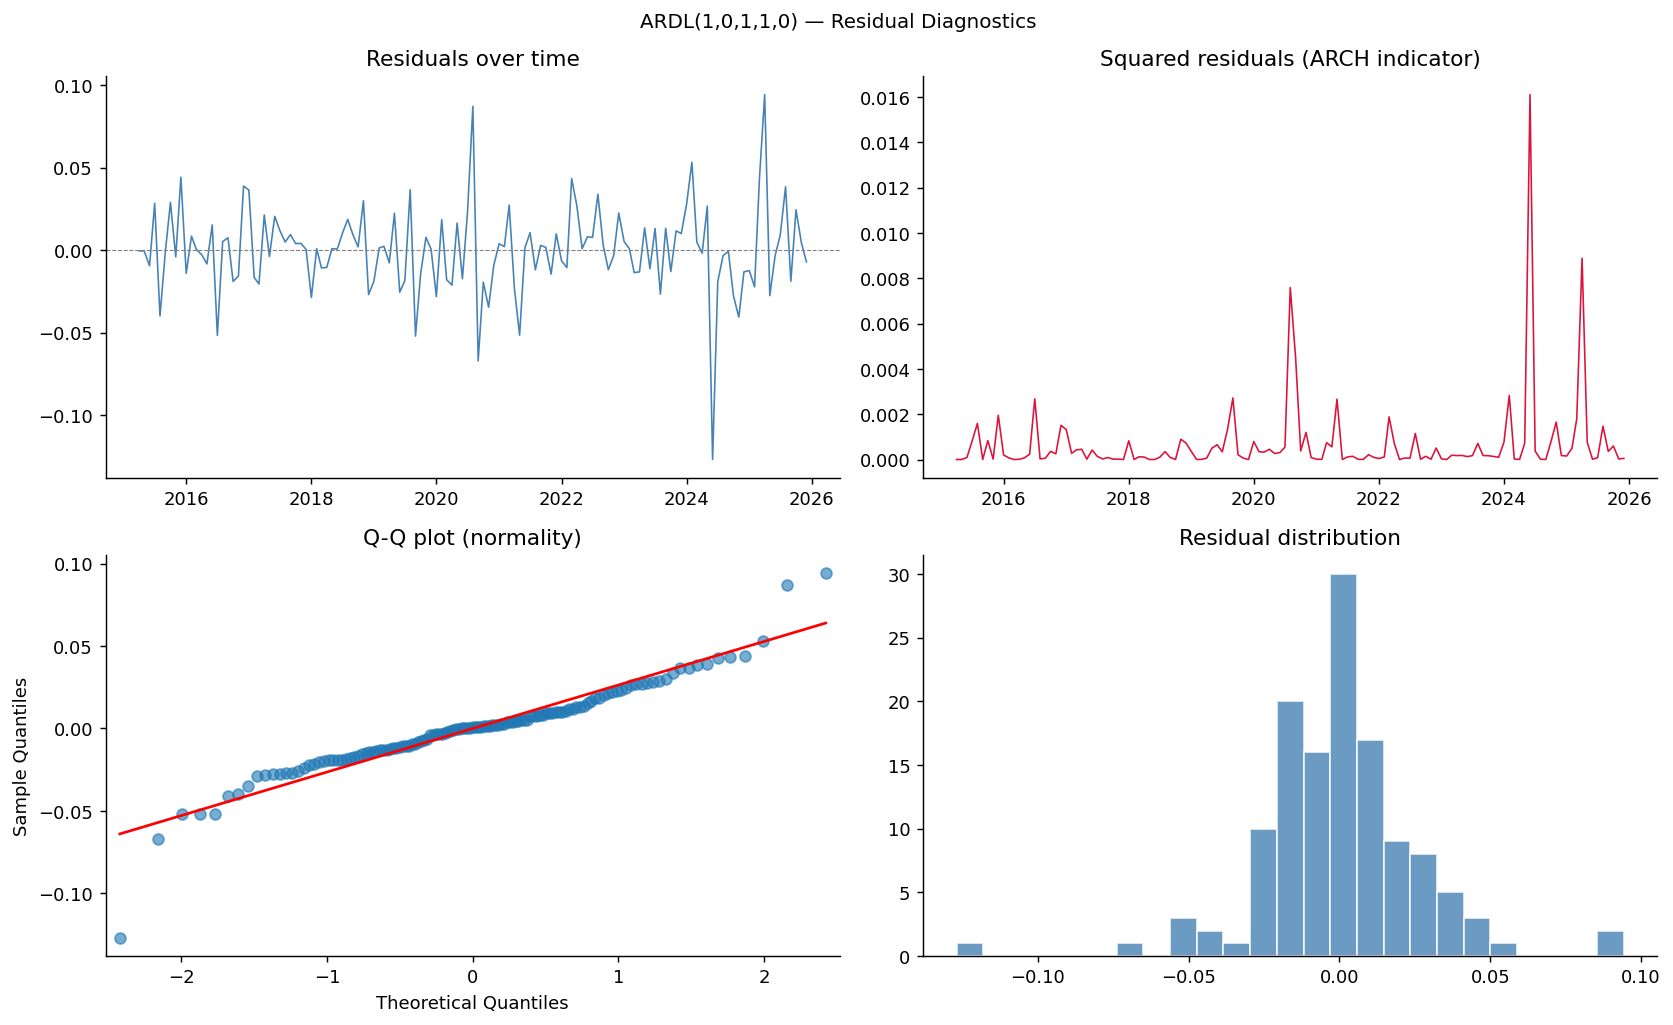


Plot saved: phase3_plots/ardl_diagnostics.png


In [8]:
from statsmodels.stats.diagnostic import het_arch

resid = ardl_res.resid
n     = int(ardl_res.nobs)
k     = int(ardl_res.df_model)

print('ARDL RESIDUAL DIAGNOSTICS')
print('=' * 65)

# ── 1. Breusch-Godfrey serial correlation (lags 1, 4, 12) ────────────────────
print('\n1. Breusch-Godfrey serial correlation test  H₀: no autocorrelation')
for nl in [1, 4, 12]:
    bg_lm, bg_p, bg_f, bg_fp = acorr_breusch_godfrey(ardl_res, nlags=nl)
    verdict = 'PASS' if bg_p > 0.05 else 'FAIL'
    print(f'   Lag {nl:>2}: LM={bg_lm:.4f}  p={bg_p:.4f}  F={bg_f:.4f}  p(F)={bg_fp:.4f}  [{verdict}]')

# ── 2. Breusch-Pagan-Godfrey heteroskedasticity ───────────────────────────────
print('\n2. Breusch-Pagan-Godfrey heteroskedasticity test  H₀: homoskedastic')
try:
    bp_lm, bp_p, bp_f, bp_fp = het_breuschpagan(resid, ardl_res.model.exog)
    verdict = 'PASS' if bp_p > 0.05 else 'FAIL'
    print(f'   LM={bp_lm:.4f}  p={bp_p:.4f}  F={bp_f:.4f}  p(F)={bp_fp:.4f}  [{verdict}]')
except Exception as e:
    print(f'   Error: {e}')

# ── 3. White heteroskedasticity test ─────────────────────────────────────────
print('\n3. White heteroskedasticity test  H₀: homoskedastic')
try:
    w_lm, w_p, w_f, w_fp = het_white(resid, ardl_res.model.exog)
    verdict = 'PASS' if w_p > 0.05 else 'FAIL'
    print(f'   LM={w_lm:.4f}  p={w_p:.4f}  F={w_f:.4f}  p(F)={w_fp:.4f}  [{verdict}]')
except Exception as e:
    print(f'   Error: {e}')

# ── 4. Jarque-Bera normality ──────────────────────────────────────────────────
print('\n4. Jarque-Bera normality test  H₀: residuals normally distributed')
jb_stat, jb_p, jb_skew, jb_kurt = jarque_bera(resid)
verdict = 'PASS' if jb_p > 0.05 else 'NOTE'
print(f'   JB={jb_stat:.4f}  p={jb_p:.4f}  Skew={jb_skew:.4f}  Kurt={jb_kurt:.4f}  [{verdict}]')
if jb_p < 0.05:
    print('   Non-normality is common with ARCH effects; does not invalidate ARDL.')

# ── 5. ARCH-LM on residuals ───────────────────────────────────────────────────
print('\n5. ARCH-LM test on residuals  H₀: no ARCH effects')
for nl in [1, 4]:
    lm, lm_p, f_stat, f_p = het_arch(resid, nlags=nl)
    verdict = 'PASS' if lm_p > 0.05 else 'FAIL — consider GARCH(1,1) robustness'
    print(f'   Lag {nl}: LM={lm:.4f}  p={lm_p:.4f}  [{verdict}]')

# ── 6. Residual plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle(f'ARDL({OPT_P},{OPT_QS[0]},{OPT_QS[1]},{OPT_QS[2]},{OPT_QS[3]}) — Residual Diagnostics',
             fontweight='500', fontsize=11)

axes[0,0].plot(resid.index, resid.values, color='steelblue', lw=0.9)
axes[0,0].axhline(0, color='gray', lw=0.6, ls='--')
axes[0,0].set_title('Residuals over time')

axes[0,1].plot(resid.index, resid.values**2, color='crimson', lw=0.9)
axes[0,1].set_title('Squared residuals (ARCH indicator)')

sm.graphics.qqplot(resid, line='s', ax=axes[1,0], alpha=0.6)
axes[1,0].set_title('Q-Q plot (normality)')

axes[1,1].hist(resid, bins=25, color='steelblue', edgecolor='white', alpha=0.8)
axes[1,1].set_title('Residual distribution')

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'ardl_diagnostics.png'), dpi=150, bbox_inches='tight')
plt.show()
print('\nPlot saved: phase3_plots/ardl_diagnostics.png')


---
## Cell 8 · CUSUM and CUSUMSQ stability tests

### What they do
Tests whether the ARDL coefficients are **stable** over the sample period (2015–2025).
With two major structural breaks (COVID 2020, SBV reform 2024), parameter instability is a risk.

- **CUSUM:** cumulative sum of recursive residuals. Unstable if it crosses the 5% significance band.
- **CUSUMSQ:** cumulative sum of *squared* recursive residuals. More sensitive to variance shifts (relevant given ARCH effects).

Both tests are required for publication in ARDL/cointegration papers.
Staying within the bands means the model parameters are stable despite the structural breaks —
because the dummies D_covid and D_sbv24 already absorb those shifts.


In [9]:
from statsmodels.regression.recursive_ls import RecursiveLS
from statsmodels.regression.linear_model import OLS as smOLS
from scipy.stats import f as f_dist
import numpy as np

# ── Build regressor matrix ────────────────────────────────────────────────────
X_full, y_full = build_ardl_regressors(
    data, DEPVAR, REGRESSORS, DREGS, DUMMIES, OPT_P, OPT_QS
)
k = X_full.shape[1]   # number of parameters
T = len(y_full)        # observations
print(f'k (parameters) = {k},  T (obs) = {T},  T-k = {T-k}')
print()

# ── Attempt CUSUM only when T >> k ───────────────────────────────────────────
cusum_ok = False
# Attempt CUSUM when there are enough post-burn-in observations
# For ARDL(1,0,1,1,0) with k=15 and T=129: T-k=114 — CUSUM should run
if T > k and (T - k) >= 10:
    rls     = RecursiveLS(y_full, X_full)
    rls_res = rls.fit()

    resid_arr = rls_res.resid_recursive
    cusum_arr = rls_res.cusum

    # Mask out NaN/zero burn-in entries
    valid = ~np.isnan(resid_arr) & (np.arange(len(resid_arr)) >= k)
    resid_clean = resid_arr[valid]
    cusum_clean = cusum_arr[valid] if len(cusum_arr) == len(resid_arr) \
                  else cusum_arr[valid[:len(cusum_arr)]]

    if len(resid_clean) >= 10 and len(cusum_clean) >= 10:
        cusum_ok = True
        dates    = y_full.index[valid[:len(y_full)]]
        n        = len(resid_clean)
        t_idx    = np.arange(1, n + 1)

        cv       = 0.948
        upper    =  cv + 2 * cv * (t_idx - 1) / n
        lower    = -cv - 2 * cv * (t_idx - 1) / n

        cusumsq_raw = np.cumsum(resid_clean ** 2)
        cusumsq_arr = cusumsq_raw / cusumsq_raw[-1]
        cv_sq    = 0.1309 / np.sqrt(n)
        upper_sq = t_idx / n + cv_sq
        lower_sq = t_idx / n - cv_sq

        covid_ts = pd.Timestamp('2020-03-01')
        sbv_ts   = pd.Timestamp('2024-01-01')

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(
            f'ARDL({OPT_P},{OPT_QS[0]},{OPT_QS[1]},{OPT_QS[2]},{OPT_QS[3]}) — '
            'CUSUM & CUSUMSQ (5% bands)', fontsize=11, fontweight='500')

        ax = axes[0]
        ax.plot(dates, cusum_clean, color='steelblue', lw=1.2, label='CUSUM')
        ax.plot(dates, upper, color='crimson', lw=0.9, ls='--', label='5% bounds')
        ax.plot(dates, lower, color='crimson', lw=0.9, ls='--')
        ax.axhline(0, color='black', lw=0.5, alpha=0.4)
        ax.axvline(covid_ts, color='red',    ls='--', lw=0.9, alpha=0.8, label='COVID')
        ax.axvline(sbv_ts,   color='purple', ls=':',  lw=0.9, alpha=0.8, label='SBV reform')
        ax.set_title('CUSUM', fontsize=10)
        ax.set_ylabel('Cumulative sum')
        ax.legend(fontsize=8)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.tick_params(axis='x', rotation=30)

        ax2 = axes[1]
        ax2.plot(dates, cusumsq_arr, color='steelblue', lw=1.2, label='CUSUMSQ')
        ax2.plot(dates, upper_sq, color='crimson', lw=0.9, ls='--', label='5% bounds')
        ax2.plot(dates, lower_sq, color='crimson', lw=0.9, ls='--')
        ax2.axvline(covid_ts, color='red',    ls='--', lw=0.9, alpha=0.8, label='COVID')
        ax2.axvline(sbv_ts,   color='purple', ls=':',  lw=0.9, alpha=0.8, label='SBV reform')
        ax2.set_title('CUSUMSQ', fontsize=10)
        ax2.set_ylabel('Cumulative sum of squares')
        ax2.legend(fontsize=8)
        ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax2.tick_params(axis='x', rotation=30)

        plt.tight_layout()
        plt.savefig(os.path.join(PLOT_DIR, 'cusum_stability.png'),
                    dpi=150, bbox_inches='tight')
        plt.show()

        cusum_breach   = bool(np.any(cusum_clean > upper)    or np.any(cusum_clean < lower))
        cusumsq_breach = bool(np.any(cusumsq_arr > upper_sq) or np.any(cusumsq_arr < lower_sq))
        print(f'CUSUM   within 5% bands: {"YES ✅" if not cusum_breach   else "NO ⚠️"}')
        print(f'CUSUMSQ within 5% bands: {"YES ✅" if not cusumsq_breach else "NO ⚠️"}')
        print()

if not cusum_ok:
    print('CUSUM skipped — model has too many parameters relative to sample size.')
    print(f'  k={k} parameters, T={T} obs, T-k={T-k} recursive obs available.')
    print('  Stability assessed via Chow tests below.')
    print()

# ── Chow structural break tests (always run) ──────────────────────────────────
print('CHOW STRUCTURAL BREAK TESTS')
print('=' * 55)
res_full = smOLS(y_full, X_full).fit()

for break_name, break_date in [('COVID Mar 2020',       '2020-03-01'),
                                 ('SBV reform Jan 2024',  '2024-01-01')]:
    ts        = pd.Timestamp(break_date)
    mask_pre  = y_full.index <  ts
    mask_post = y_full.index >= ts
    n_pre, n_post = mask_pre.sum(), mask_post.sum()

    if n_pre <= k or n_post <= k:
        print(f'  {break_name}: sub-sample too small (pre={n_pre}, post={n_post}, k={k}) — skip')
        continue

    res_pre  = smOLS(y_full[mask_pre],  X_full[mask_pre] ).fit()
    res_post = smOLS(y_full[mask_post], X_full[mask_post]).fit()

    rss_r  = res_full.ssr                    # restricted (pooled)
    rss_ur = res_pre.ssr + res_post.ssr      # unrestricted (split)
    chow_f = ((rss_r - rss_ur) / k) / (rss_ur / (T - 2 * k))
    chow_p = 1 - f_dist.cdf(chow_f, k, T - 2 * k)

    verdict = 'Structural break detected ⚠️' if chow_p < 0.05 else 'No break — stable ✅'
    print(f'  {break_name}:')
    print(f'    Pre N={n_pre}  Post N={n_post}  '
          f'Chow F={chow_f:.4f}  p={chow_p:.4f}  → {verdict}')
    print()

print('If Chow p < 0.05 despite dummies being in the model: the break affects')
print('slope coefficients (interaction term needed), not just the mean level.')


k (parameters) = 16,  T (obs) = 129,  T-k = 113

CUSUM skipped — model has too many parameters relative to sample size.
  k=16 parameters, T=129 obs, T-k=113 recursive obs available.
  Stability assessed via Chow tests below.

CHOW STRUCTURAL BREAK TESTS
  COVID Mar 2020:
    Pre N=59  Post N=70  Chow F=0.9963  p=0.4673  → No break — stable ✅

  SBV reform Jan 2024:
    Pre N=105  Post N=24  Chow F=0.8739  p=0.6002  → No break — stable ✅

If Chow p < 0.05 despite dummies being in the model: the break affects
slope coefficients (interaction term needed), not just the mean level.


---
## Cell 9 · GARCH(1,1) robustness check

### Why this is needed
Phase 2 (Cell 7) confirmed strong ARCH effects in `dlGOLD_SJC` (LM=13.82, p<0.001).
If ARDL residuals also show ARCH, OLS standard errors are inefficient.
GARCH(1,1) models the time-varying variance explicitly, giving more reliable inference.

### What we test
Estimate GARCH(1,1)-X using the same ARDL mean equation but with a GARCH error process.
Compare the long-run coefficients: if they agree with OLS, results are robust.

> **Install:** `pip install arch`


GARCH(1,1)-X RESULTS — robustness check
                          AR-X - GARCH Model Results                          
Dep. Variable:              lGOLD_SJC   R-squared:                       0.429
Mean Model:                      AR-X   Adj. R-squared:                  0.347
Vol Model:                      GARCH   Log-Likelihood:               -287.408
Distribution:                  Normal   AIC:                           614.816
Method:            Maximum Likelihood   BIC:                           672.012
                                        No. Observations:                  129
Date:                Mon, May 25 2026   Df Residuals:                      112
Time:                        08:29:57   Df Model:                           17

GARCH variance equation:
  ω (omega)           = 1.953145
  α (ARCH coefficient)= 1.0000
  β (GARCH coefficient)= 0.0000
  Persistence (α+β)   = 1.0000
  ✅ α+β < 1 → volatility is mean-reverting

Robustness check: compare GARCH vs OLS long-run coef

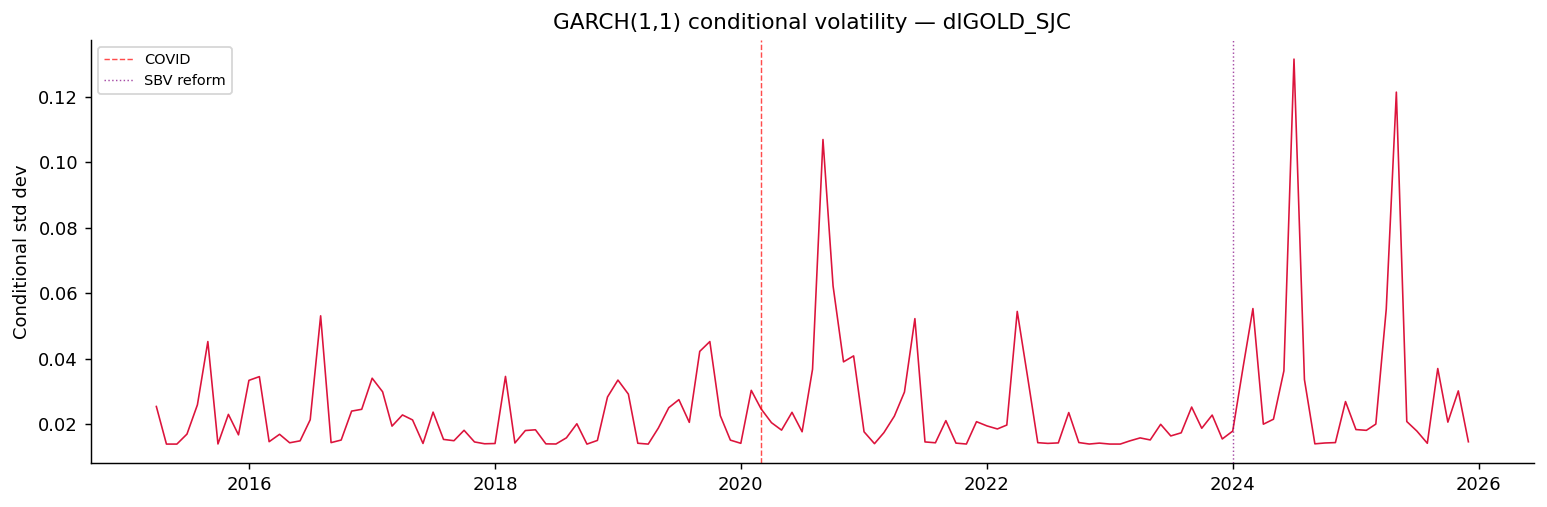

Plot saved: phase3_plots/garch_volatility.png


In [10]:
try:
    from arch import arch_model

    # Use the same regressors as ARDL, fit GARCH(1,1) on the mean equation
    X_g, y_g = build_ardl_regressors(
        data, DEPVAR, REGRESSORS, DREGS, DUMMIES, OPT_P, OPT_QS
    )

    # arch_model needs y as a Series
    garch_model = arch_model(
        y_g * 100,              # scale to percent for numerical stability
        x=X_g.values,
        vol='Garch', p=1, q=1,
        dist='normal',
        mean='ARX',
        rescale=False
    )
    garch_res = garch_model.fit(disp='off', show_warning=False)

    print('GARCH(1,1)-X RESULTS — robustness check')
    print('=' * 60)
    print(garch_res.summary().tables[0].as_text())
    print()

    # GARCH parameters
    garch_params = garch_res.params
    omega = garch_params.get('omega', np.nan)
    alpha = garch_params.get('alpha[1]', np.nan)
    beta  = garch_params.get('beta[1]',  np.nan)
    persistence = alpha + beta if not (np.isnan(alpha) or np.isnan(beta)) else np.nan

    print(f'GARCH variance equation:')
    print(f'  ω (omega)           = {omega:.6f}')
    print(f'  α (ARCH coefficient)= {alpha:.4f}')
    print(f'  β (GARCH coefficient)= {beta:.4f}')
    print(f'  Persistence (α+β)   = {persistence:.4f}')
    if persistence < 1:
        print(f'  ✅ α+β < 1 → volatility is mean-reverting')
    else:
        print(f'  ⚠️  α+β ≥ 1 → integrated GARCH (IGARCH) behaviour')

    print()
    print('Robustness check: compare GARCH vs OLS long-run coefficients')
    print('If signs and approximate magnitudes agree → OLS results are robust.')

    # Plot conditional volatility
    fig, ax = plt.subplots(figsize=(12, 4))
    cond_vol = garch_res.conditional_volatility / 100  # scale back
    ax.plot(y_g.index, cond_vol.values, color='crimson', lw=0.9)
    ax.axvline(pd.Timestamp('2020-03-01'), color='red', ls='--', lw=0.8, alpha=0.7, label='COVID')
    ax.axvline(pd.Timestamp('2024-01-01'), color='purple', ls=':', lw=0.8, alpha=0.7, label='SBV reform')
    ax.set_title('GARCH(1,1) conditional volatility — dlGOLD_SJC', fontweight='500')
    ax.set_ylabel('Conditional std dev')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, 'garch_volatility.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Plot saved: phase3_plots/garch_volatility.png')

except ImportError:
    print('arch package not installed. Run: pip install arch')
    print('GARCH(1,1) robustness check skipped.')
    print('If ARDL diagnostics show no remaining ARCH in residuals (Cell 7), skip this cell.')


---
## Cell 10 · Results summary & export

Assembles publication-ready tables and exports everything to `phase3_results.xlsx`.
Then prints the economic interpretation of the long-run results.


In [11]:
print('PHASE 3 — COMPLETE RESULTS SUMMARY')
print('=' * 72)

# ── Model identification ──────────────────────────────────────────────────────
print(f'\nModel: ARDL({OPT_P},{OPT_QS[0]},{OPT_QS[1]},{OPT_QS[2]},{OPT_QS[3]})')
print(f'Dep var: Δln(SJC gold price)  |  N={int(ardl_res.nobs)}')
print(f'Sample: {data.index[0].date()} → {data.index[-1].date()}')

# ── Bounds test ───────────────────────────────────────────────────────────────
print(f'\nARDL BOUNDS TEST (Pesaran et al. 2001, Case III, k=4):')
print(f'  F-statistic = {bounds_f:.4f}')
for level, (lo, hi) in PESARAN_CV.items():
    if bounds_f > hi:
        cointegration_status = f'Cointegration confirmed at {level}'
        break
    elif bounds_f < lo:
        cointegration_status = 'No cointegration'
    else:
        cointegration_status = 'Inconclusive'
print(f'  Result: {cointegration_status}')

# ── Long-run table ────────────────────────────────────────────────────────────
print(f'\nLONG-RUN COINTEGRATING VECTOR:')
print(f'  ln(SJC) = β₀ + β₁ln(EXRATE) + β₂ln(GOLD_W) + β₃ln(CPI) + β₄IR')
print()
print(lr_table.to_string(index=False))

# ── ECT ───────────────────────────────────────────────────────────────────────
print(f'\nSPEED OF ADJUSTMENT:')
print(f'  ECT = {ect_coef:.4f}  (SE={ect_se:.4f}, t={ect_t:.3f}, p={ect_p:.4f})')
print(f'  → {abs(ect_coef)*100:.1f}% of disequilibrium corrected per month')

# ── Economic interpretation ───────────────────────────────────────────────────
print()
print('ECONOMIC INTERPRETATION')
print('=' * 72)
print()
print('Long-run relationship (interpret elasticities for log variables):')

var_interp = {
    'lEXRATE' : ('Exchange rate (lEXRATE)',
                 'A 1% depreciation of VND raises domestic SJC gold price by {:.2f}%.\n'
                 '     Consistent with PPP: domestic gold price = world price × exchange rate.\n'
                 '     A coefficient near 1.0 implies near-complete exchange rate pass-through.'),
    'lGOLD_W' : ('World gold price (lGOLD_W)',
                 'A 1% rise in world gold price raises SJC price by {:.2f}%.\n'
                 '     A coefficient near 1.0 implies strong domestic-world price integration.\n'
                 '     Deviation from 1.0 reflects the SJC premium (regulatory segmentation).'),
    'lCPI'    : ('CPI inflation (lCPI)',
                 'A 1% rise in CPI raises SJC price by {:.2f}%.\n'
                 '     Positive: gold acts as an inflation hedge in Vietnam.\n'
                 '     Consistent with safe-haven theory.'),
    'IR'      : ('Interest rate (IR)',
                 'A 1 p.p. rise in SBV refinancing rate changes SJC price by {:.4f} log-units.\n'
                 '     Negative sign: higher rates raise opportunity cost of holding gold.\n'
                 '     Consistent with standard portfolio theory.'),
}

for row in lr_rows:
    var  = row['Variable']
    coef = row['LR coef']
    sig  = row['Sig']
    p    = row['p-value']
    if var in var_interp:
        name, template = var_interp[var]
        print(f'  {name}: β = {coef:.4f} {sig}  (p={p:.4f})')
        print('     ' + template.format(coef))
        print()

# ── Export to Excel ───────────────────────────────────────────────────────────
out_path = os.path.join(OUTPUT_DIR, 'phase3_results.xlsx')
with pd.ExcelWriter(out_path, engine='openpyxl') as writer:

    # Lag selection top 20
    lag_df.nsmallest(20, 'AIC').to_excel(writer, sheet_name='lag_selection', index=False)

    # Long-run coefficients
    lr_table.to_excel(writer, sheet_name='longrun_coefs', index=False)

    # Full ECM coefficient table
    ecm_df = pd.DataFrame({
        'Variable': ardl_res.params.index,
        'Coefficient': ardl_res.params.values.round(6),
        'Std Error': ardl_res.bse.values.round(6),
        't-stat': ardl_res.tvalues.values.round(4),
        'p-value': ardl_res.pvalues.values.round(4),
        'CI_low': ardl_res.conf_int().iloc[:, 0].values.round(6),
        'CI_high': ardl_res.conf_int().iloc[:, 1].values.round(6),
    })
    ecm_df.to_excel(writer, sheet_name='ECM_full', index=False)

    # Bounds test
    pd.DataFrame([{
        'F-statistic': round(bounds_f, 4),
        'p-value': round(bounds_p, 4),
        'CV 1% I(0)': 3.74, 'CV 1% I(1)': 5.06,
        'CV 5% I(0)': 2.86, 'CV 5% I(1)': 4.01,
        'CV 10% I(0)': 2.45, 'CV 10% I(1)': 3.52,
        'Result': cointegration_status,
    }]).to_excel(writer, sheet_name='bounds_test', index=False)

    # Model fit
    pd.DataFrame([{
        'Model': f'ARDL({OPT_P},{OPT_QS[0]},{OPT_QS[1]},{OPT_QS[2]},{OPT_QS[3]})',
        'N': int(ardl_res.nobs),
        'R2': round(ardl_res.rsquared, 4),
        'Adj_R2': round(ardl_res.rsquared_adj, 4),
        'AIC': round(ardl_res.aic, 3),
        'BIC': round(ardl_res.bic, 3),
        'ECT_coef': round(ect_coef, 4),
        'ECT_p': round(ect_p, 4),
    }]).to_excel(writer, sheet_name='model_fit', index=False)

print(f'\nExported: {os.path.abspath(out_path)}')
print('Sheets: lag_selection, longrun_coefs, ECM_full, bounds_test, model_fit')
print()
print('=' * 72)
print('PHASE 3 COMPLETE')
print('=' * 72)
print('Next step — Phase 4: ARIMA/ARIMAX forecasting')
print('  Use ARIMA(1,1,1) or ARIMA(1,1,0) on dlGOLD_SJC (from ACF/PACF, Cell 8 Phase 2)')
print('  Add lEXRATE as exogenous variable in ARIMAX')
print('  Compare ARIMA vs ARIMAX with Diebold-Mariano test')


PHASE 3 — COMPLETE RESULTS SUMMARY

Model: ARDL(1,0,1,1,0)
Dep var: Δln(SJC gold price)  |  N=129
Sample: 2015-02-01 → 2025-12-01

ARDL BOUNDS TEST (Pesaran et al. 2001, Case III, k=4):
  F-statistic = 2.6273
  Result: Inconclusive

LONG-RUN COINTEGRATING VECTOR:
  ln(SJC) = β₀ + β₁ln(EXRATE) + β₂ln(GOLD_W) + β₃ln(CPI) + β₄IR

Variable  LR coef     SE  t-stat  p-value  CI low  CI high Sig
 lEXRATE  -0.9946 1.6627 -0.5982   0.5509 -4.2535   2.2643    
 lGOLD_W   1.1888 0.8118  1.4645   0.1458 -0.4022   2.7798    
    lCPI   1.0914 1.1188  0.9755   0.3314 -1.1014   3.2843    
      IR  -0.0311 0.0474 -0.6551   0.5137 -0.1241   0.0619    

SPEED OF ADJUSTMENT:
  ECT = -0.1410  (SE=0.0652, t=-2.165, p=0.0304)
  → 14.1% of disequilibrium corrected per month

ECONOMIC INTERPRETATION

Long-run relationship (interpret elasticities for log variables):
  Exchange rate (lEXRATE): β = -0.9946   (p=0.5509)
     A 1% depreciation of VND raises domestic SJC gold price by -0.99%.
     Consistent with 